<a href="https://colab.research.google.com/github/Muntaha369/Waste-Classifier/blob/main/Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models
from tensorflow.keras.utils import image_dataset_from_directory  # converts image into 2d array

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phenomsg/waste-classification")

print("Path to dataset files:", path)

100%|██████████| 1.02G/1.02G [00:51<00:00, 21.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/phenomsg/waste-classification/versions/1


In [17]:
waste_dataset = image_dataset_from_directory(
    f"{path}",
    image_size=(128, 128),
    batch_size=32
)

Found 2902 files belonging to 4 classes.


In [18]:
# you can't directly access image like waste_dataset[0] because tensorflow converted it into a batch not a dict or a tuples

# To access a specific image it's better to itterate over a batchsize
for images, labels in waste_dataset.take(1):
    print("Shape of images batch:", images.shape)
    print("Shape of labels batch:", labels.shape)
    print("Example labels (first 5):")
    print(labels[:5].numpy())

#Anoter way to iterate over a batch
# images, labels = next(iter(waste_dataset)) # iter  --> turns waste_dataset into an iterator we can pull batches from
                                             # next  --> grabs the next batch; since our Dataset returns (image, label) pairs, each batch here comes out as a tuple: (images, labels)

# print(images[0]) # this is a particular image from a batch

print("\nClass Names:")
print(waste_dataset.class_names)

Shape of images batch: (32, 128, 128, 3)
Shape of labels batch: (32,)
Example labels (first 5):
[3 2 2 0 1]

Class Names:
['Hazardous', 'Non-Recyclable', 'Organic', 'Recyclable']


In [19]:
images, labels = next(iter(waste_dataset))

In [20]:
print(images.shape)
print(labels.shape)

(32, 128, 128, 3)
(32,)


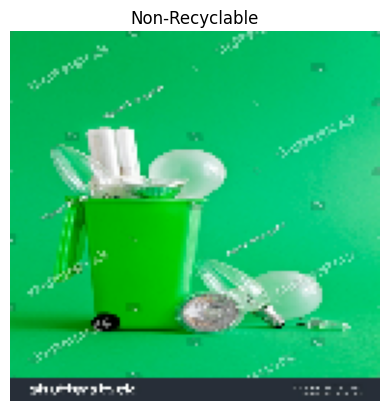

In [21]:
plt.imshow(images[31].numpy().astype("uint8")) # Converts the first TensorFlow image to a NumPy uint8 array (uint8 converts numpy array of floats to interger) and displays it
plt.title(waste_dataset.class_names[labels[0]])
plt.axis("off")
plt.show()

In [22]:
val_split = 0.2
len_dataset = len(waste_dataset)
test_batches = int(val_split * len_dataset)

train_ds = waste_dataset.skip(test_batches)
test_ds = waste_dataset.take(test_batches)

print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(test_ds)}")

Number of training batches: 73
Number of validation batches: 18


In [16]:
# Re-define and re-compile the model to ensure the input shape and output units are updated
perceptron = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(len(waste_dataset.class_names), activation="softmax")
])
perceptron.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_percp = perceptron.fit(train_ds, epochs=5, batch_size=32, validation_data=(test_ds), verbose=1)

Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 474ms/step - accuracy: 0.2691 - loss: 3771249.0000 - val_accuracy: 0.3854 - val_loss: 2888411.0000
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 79s 435ms/step - accuracy: 0.2786 - loss: 3130374.7500 - val_accuracy: 0.2049 - val_loss: 3488022.5000
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 439ms/step - accuracy: 0.3005 - loss: 3172117.7500 - val_accuracy: 0.3906 - val_loss: 2506452.7500
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 503ms/step - accuracy: 0.3315 - loss: 2823245.5000 - val_accuracy: 0.2396 - val_loss: 5393424.0000
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 435ms/step - accuracy: 0.3156 - loss: 2998347.5000 - val_accuracy: 0.3819 - val_loss: 676778.3750


In [23]:
acc_percp = perceptron.evaluate( test_ds, verbose=0)[1]

acc_percp

0.4131944477558136

In [24]:
ann = Sequential([
    Flatten(input_shape=(128,128, 3)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(len(waste_dataset.class_names), activation="softmax")
])

ann.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_ann = ann.fit(train_ds, epochs=5, batch_size=32, validation_data=(test_ds), verbose=1)

Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 435ms/step - accuracy: 0.2700 - loss: 1538.6965 - val_accuracy: 0.2500 - val_loss: 679.6519
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 442ms/step - accuracy: 0.3117 - loss: 518.5964 - val_accuracy: 0.4236 - val_loss: 682.0784
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 448ms/step - accuracy: 0.3650 - loss: 317.9122 - val_accuracy: 0.3177 - val_loss: 180.6026
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 431ms/step - accuracy: 0.3852 - loss: 212.1765 - val_accuracy: 0.3229 - val_loss: 157.1782
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 488ms/step - accuracy: 0.3637 - loss: 248.1115 - val_accuracy: 0.3316 - val_loss: 180.2232


In [25]:
acc_ann = ann.evaluate(test_ds,verbose=0)[1]

acc_ann

0.3177083432674408

### Building a Convolutional Neural Network (CNN) Model

CNNs are particularly effective for image data. This model will include convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification.

In [26]:
cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

None


Now, let's train our CNN model. We'll use the same training and validation datasets as before.

In [27]:
history_cnn = cnn.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 48s 490ms/step - accuracy: 0.2764 - loss: 21.4713 - val_accuracy: 0.3403 - val_loss: 1.3691
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 428ms/step - accuracy: 0.3319 - loss: 1.3586 - val_accuracy: 0.3420 - val_loss: 1.3731
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 490ms/step - accuracy: 0.3495 - loss: 1.3254 - val_accuracy: 0.3524 - val_loss: 1.3534
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 494ms/step - accuracy: 0.3684 - loss: 1.3041 - val_accuracy: 0.3594 - val_loss: 1.3670
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 450ms/step - accuracy: 0.3796 - loss: 1.2828 - val_accuracy: 0.3681 - val_loss: 1.4478
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 442ms/step - accuracy: 0.4196 - loss: 1.2160 - val_accuracy: 0.3611 - val_loss: 1.6052
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 445ms/step - accuracy: 0.4144 - loss: 1.2629 - val_accuracy: 0.3507 - val_loss: 1.3802
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 490ms/step - accuracy: 0.4308 - loss: 1.2065 - val_acc

After training, we will evaluate the CNN's performance on the test set.

In [28]:
acc_cnn = cnn.evaluate(test_ds, verbose=0)[1]
print(f"CNN Test Accuracy: {acc_cnn:.4f}")

CNN Test Accuracy: 0.4167


### Retraining the CNN Model with More Epochs

To further improve the model's accuracy, let's train the CNN for more epochs. This can help the model converge better and capture more complex patterns in the data.

In [29]:
# Continue training the existing cnn model for more epochs
history_cnn_extended = cnn.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 488ms/step - accuracy: 0.5013 - loss: 1.0458 - val_accuracy: 0.4479 - val_loss: 1.3405
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 492ms/step - accuracy: 0.5279 - loss: 0.9781 - val_accuracy: 0.4705 - val_loss: 1.3487
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 446ms/step - accuracy: 0.5529 - loss: 0.9181 - val_accuracy: 0.4896 - val_loss: 1.2904
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 460ms/step - accuracy: 0.5770 - loss: 0.9193 - val_accuracy: 0.4861 - val_loss: 1.3346
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 450ms/step - accuracy: 0.6131 - loss: 0.8300 - val_accuracy: 0.4722 - val_loss: 1.4699
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 452ms/step - accuracy: 0.6161 - loss: 0.8406 - val_accuracy: 0.4896 - val_loss: 1.5321
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 456ms/step - accuracy: 0.6101 - loss: 0.8633 - val_accuracy: 0.5278 - val_loss: 1.3747
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 457ms/step - accuracy: 0.6595 - loss: 0.7642 - val_accu

Now, let's evaluate the CNN's performance after extended training.

In [30]:
acc_cnn_extended = cnn.evaluate(test_ds, verbose=0)[1]
print(f"CNN Test Accuracy after extended training: {acc_cnn_extended:.4f}")

CNN Test Accuracy after extended training: 0.5243


### Implementing Data Augmentation

Data augmentation artificially increases the size of the training dataset by applying random transformations to the images. This helps the model generalize better and reduces overfitting.

In [31]:
from tensorflow.keras import layers

data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

Now, let's create a new CNN model that incorporates these data augmentation layers at the beginning. This model will be trained from scratch with the augmented data.

In [32]:
cnn_augmented = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(128, 128, 3)), # Rescale input to [0,1] range
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_augmented.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_augmented.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Let's train this new CNN model with data augmentation for 20 epochs.

In [33]:
history_cnn_augmented = cnn_augmented.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 410ms/step - accuracy: 0.3259 - loss: 1.4037 - val_accuracy: 0.3455 - val_loss: 1.3373
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 450ms/step - accuracy: 0.3874 - loss: 1.3085 - val_accuracy: 0.4184 - val_loss: 1.2756
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 425ms/step - accuracy: 0.3908 - loss: 1.3021 - val_accuracy: 0.4132 - val_loss: 1.3052
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 499ms/step - accuracy: 0.4097 - loss: 1.2740 - val_accuracy: 0.4288 - val_loss: 1.2221
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 450ms/step - accuracy: 0.4256 - loss: 1.2570 - val_accuracy: 0.4653 - val_loss: 1.2258
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 493ms/step - accuracy: 0.4321 - loss: 1.2398 - val_accuracy: 0.4410 - val_loss: 1.2146
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 447ms/step - accuracy: 0.4411 - loss: 1.2271 - val_accuracy: 0.4514 - val_loss: 1.2414
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 458ms/step - accuracy: 0.4407 - loss: 1.2263 - val_accu

Finally, let's evaluate the performance of the CNN model with data augmentation on the test set.

In [34]:
acc_cnn_augmented = cnn_augmented.evaluate(test_ds, verbose=0)[1]
print(f"CNN Test Accuracy with Data Augmentation: {acc_cnn_augmented:.4f}")

CNN Test Accuracy with Data Augmentation: 0.4844


### Building a Deeper CNN Model

To further enhance the model's learning capabilities, let's create a deeper CNN by adding more convolutional layers and increasing the number of filters. This can help the model extract more intricate features from the images.

In [35]:
cnn_deeper = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)), # Rescale input to [0,1] range
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'), # Added layer
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'), # Increased units
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


Now, let's train this deeper CNN model for 20 epochs, similar to our previous attempts.

In [36]:
history_cnn_deeper = cnn_deeper.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 461ms/step - accuracy: 0.3379 - loss: 1.3569 - val_accuracy: 0.3125 - val_loss: 1.3113
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 477ms/step - accuracy: 0.3947 - loss: 1.2887 - val_accuracy: 0.4097 - val_loss: 1.2657
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 427ms/step - accuracy: 0.4063 - loss: 1.2691 - val_accuracy: 0.3906 - val_loss: 1.2778
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 474ms/step - accuracy: 0.4312 - loss: 1.2415 - val_accuracy: 0.4219 - val_loss: 1.2489
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 488ms/step - accuracy: 0.4506 - loss: 1.2207 - val_accuracy: 0.4549 - val_loss: 1.2160
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 441ms/step - accuracy: 0.4488 - loss: 1.2240 - val_accuracy: 0.3872 - val_loss: 1.2835
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 494ms/step - accuracy: 0.4699 - loss: 1.1921 - val_accuracy: 0.4740 - val_loss: 1.1877
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 478ms/step - accuracy: 0.4828 - loss: 1.1568 - val_accu

Finally, we will evaluate the performance of our deeper CNN model on the test set.

In [37]:
acc_cnn_deeper = cnn_deeper.evaluate(test_ds, verbose=0)[1]
print(f"Deeper CNN Test Accuracy: {acc_cnn_deeper:.4f}")

Deeper CNN Test Accuracy: 0.7326


### Adding Dropout for Regularization

To prevent overfitting and further improve generalization, we will add Dropout layers to our deeper CNN model. Dropout randomly sets a fraction of input units to zero during training, which helps in creating a more robust model.

In [41]:


cnn_deeper_dropout = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Added Dropout to the dense layer
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper_dropout.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:
cnn_deeper_dropout = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Added Dropout to the dense layer
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper_dropout.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [40]:
history_cnn_deeper_dropout = cnn_deeper_dropout.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 55s 539ms/step - accuracy: 0.3138 - loss: 1.4326 - val_accuracy: 0.3264 - val_loss: 1.3624
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 449ms/step - accuracy: 0.3392 - loss: 1.3546 - val_accuracy: 0.3872 - val_loss: 1.3416
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.3985 - loss: 1.2996 - val_accuracy: 0.4115 - val_loss: 1.3031
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 446ms/step - accuracy: 0.4144 - loss: 1.2746 - val_accuracy: 0.4219 - val_loss: 1.2653
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.4222 - loss: 1.2642 - val_accuracy: 0.4010 - val_loss: 1.2927
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 445ms/step - accuracy: 0.4140 - loss: 1.2599 - val_accuracy: 0.4201 - val_loss: 1.2611
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 437ms/step - accuracy: 0.4261 - loss: 1.2504 - val_accuracy: 0.4288 - val_loss: 1.2294
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 507ms/step - accuracy: 0.4183 - loss: 1.2507 - val_accu

In [42]:
acc_cnn_deeper_dropout = cnn_deeper_dropout.evaluate(test_ds, verbose=0)[1]
print(f"Deeper CNN Test Accuracy with Dropout: {acc_cnn_deeper_dropout:.4f}")

Deeper CNN Test Accuracy with Dropout: 0.1788


In [43]:
cnn_deeper_dropout_adjusted = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1), # Adjusted Dropout rate
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1), # Adjusted Dropout rate
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1), # Adjusted Dropout rate
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3), # Adjusted Dropout rate for dense layer
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper_dropout_adjusted.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper_dropout_adjusted.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [44]:
history_cnn_deeper_dropout_adjusted = cnn_deeper_dropout_adjusted.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 50s 489ms/step - accuracy: 0.3160 - loss: 1.3873 - val_accuracy: 0.3698 - val_loss: 1.3298
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 434ms/step - accuracy: 0.3856 - loss: 1.3107 - val_accuracy: 0.3767 - val_loss: 1.3401
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.3968 - loss: 1.2967 - val_accuracy: 0.4184 - val_loss: 1.2574
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.4071 - loss: 1.2635 - val_accuracy: 0.4149 - val_loss: 1.2846
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 443ms/step - accuracy: 0.4037 - loss: 1.2716 - val_accuracy: 0.4219 - val_loss: 1.2712
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 493ms/step - accuracy: 0.4170 - loss: 1.2641 - val_accuracy: 0.4427 - val_loss: 1.2617
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 420ms/step - accuracy: 0.4308 - loss: 1.2454 - val_accuracy: 0.4358 - val_loss: 1.2403
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 487ms/step - accuracy: 0.4295 - loss: 1.2378 - val_accu

In [45]:
acc_cnn_deeper_dropout_adjusted = cnn_deeper_dropout_adjusted.evaluate(test_ds, verbose=0)[1]
print(f"Deeper CNN Test Accuracy with Adjusted Dropout: {acc_cnn_deeper_dropout_adjusted:.4f}")

Deeper CNN Test Accuracy with Adjusted Dropout: 0.6024
